# Regular 1

| | |
|---|---|
| Thời gian | 90 phút |
| Hình thức | Làm trực tiếp trên notebook này. Không xóa đề. |

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên kết quả vừa tính — không copy insight có sẵn.
3. Chạy cell theo thứ tự từ trên xuống.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load | không tính điểm |
| 1 | Inspection | 2,5 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (Univariate & Multivariate) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |
| Bonus | | +2,0 |
| **Tối đa** | | **12,0** |


# Import thư viện


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Dataset Description

Cột gốc (file CSV):

- show_id: mã từng title
- type: Movie hoặc TV Show
- title: tên phim hoặc chương trình
- director: đạo diễn
- cast: diễn viên
- country: quốc gia sản xuất; 
- date_added: ngày thêm 
- release_year: năm phát hành gốc
- rating: xếp hạng độ tuổi
- duration: thời lượng dạng chữ. Movie là phút (90 min), TV Show là số mùa (2 Seasons)
- listed_in: thể loại; có thể nhiều tag
- description: tóm tắt nội dung


# Load data

Đọc file data.csv vào df.


In [2]:
# df = ?
df = pd.read_csv('data.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Phần 1 — Inspection (**2,5 đ**)

Khám phá dữ liệu gốc df trước khi clean.


### Câu 1.1 — In 10 dòng đầu (**0,1 đ**)


In [3]:
# Your code here
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


### Câu 1.2 — In thông tin dataframe (**0,1 đ**)

Số dòng, cột, dtype, non-null.


In [4]:
# Your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Câu 1.3 — Thống kê mô tả (**0,3 đ**)

Cho biết thống kê mô tả của dataframe, thêm 5%, 15%, 30%.


In [5]:
# Your code here
df.describe(percentiles=[0.05,0.15,0.3])


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
5%,1997.000000
15%,2009.000000
30%,2015.000000
50%,2017.000000
max,2021.000000


### Câu 1.4 — Số giá trị duy nhất mỗi cột (**0,1 đ**)


In [6]:
# Your code here
print(df.nunique())

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64


### Câu 1.5 — Liệt kê giá trị type và rating (**0,1 đ**)


In [7]:
# Your code here
print("Type: ",df['type'].unique())
print("Ranting: ",df['rating'].unique())

Type:  ['Movie' 'TV Show']
Ranting:  ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


### Câu 1.6 — Duplicate (**0,5 đ**)

Đếm số dòng trùng.

- Nếu = 0: ghi không có trùng, giữ nguyên dữ liệu.
- Nếu > 0: quyết định xóa hay giữ. Nếu xóa thì chạy code và so sánh số dòng trước/sau. Giải thích.


In [8]:
# n_dup = ?
# print("Số dòng trùng:", n_dup)
n_dup = df.duplicated().sum()
print("Số dòng trùng:", n_dup)

Số dòng trùng: 0


### Missing data (**1,3 đ** gồm câu 1.7–1.10)


### Câu 1.7 — Missing theo từng cột (**0,2 đ**)

Đếm missing theo từng cột, sắp xếp giảm dần.


In [9]:
# Your code here
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Câu 1.8 — Tổng missing và % trên dataset (**0,4 đ**)

Tổng missing là bao nhiêu, quy ra % trên toàn dataset là bao nhiêu (2 chữ số thập phân).


In [10]:
# print("Tổng số missing: ", ?)
# print("Phần trăm missing: ",?)
null_count = df.isnull().sum().sum()
print("Tổng số missing: ", null_count)
data_cells = df.shape[1] *df.shape[0]
print(f"Phần trăm missing: {((null_count/data_cells)*100):.2f}%")


Tổng số missing:  4307
Phần trăm missing: 4.08%


### Câu 1.9 — Bảng missing count và % (**0,3 đ**)

Tính số missing và % missing theo từng cột. Chỉ hiện cột đang thiếu. Làm tròn 2 chữ số thập phân.


In [11]:
# missing = ?
# missing_pct = ? # pct %
# missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
# missing_df = # > 0
# missing_df
missing = df.isnull().sum()
missing_pct = (missing / df.shape[0] * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
display(missing_df)


,missing_count,missing_pct
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### Câu 1.10 — Barplot missing (**0,4 đ**)

Vẽ barplot % missing theo cột. Có title và nhãn trục.


Text(0.5, 1.0, 'Phần trăm missing theo cột')

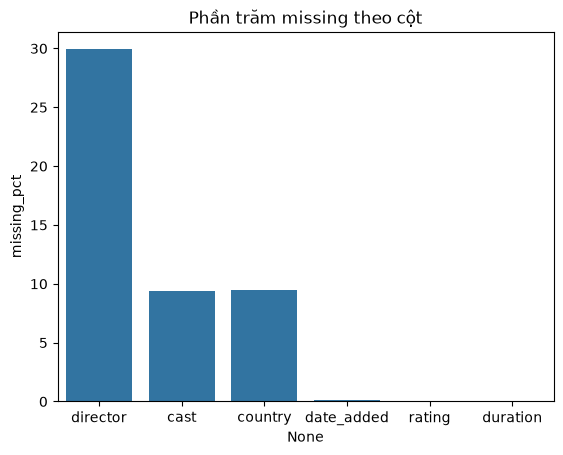

In [12]:
# Vẽ barplot % missing theo cột. Có title và nhãn trục.
# Gợi ý: sns.barplot với missing_df
# Your code here
sns.barplot(data = missing_df, x =missing_df.index, y= missing_df["missing_pct"])
plt.title("Phần trăm missing theo cột")

# Phần 2 — Data Cleaning & Feature Engineering (**3,5 đ**)


### Câu 2.1 — tạo bản sao (**0,2 đ**)

Tạo bản sao từ df, gán vào df_clean.


In [13]:
# Your code here
df_clean = df.copy()

### Câu 2.2 — Cột phân loại đang thiếu (**0,3 đ**)

Kiểu phân loại (Category/Qualitative) có cột nào đang thiếu dữ liệu không?


In [14]:
# Your code here
category_missing = df_clean.select_dtypes(['object','category']).isnull().sum()
print("các cột đang bị thiếu dữ liệu\n",category_missing[category_missing>0])

các cột đang bị thiếu dữ liệu
 director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [15]:
df['director'].shape[0]

8807

### Câu 2.3 — Xóa hay impute (**1,0 đ**)

Nếu thiếu:
- Có nên xóa không? Tại sao? Thực thi lệnh.
- Nếu không xóa thì impute dữ liệu gì, tại sao? Thực thi lệnh.


In [16]:
# Your code here


# Không nên xóa vì cột đang thiếu quá nhiều ô, thiếu 2634 ô trên tổng 8807 ô
# CỘt cast và country cũng thiếu khá nhiều

# Cách impute

# đối với các cột director, cast vaf country thì sẽ điền là "Unknow" biểu thị là chưa ghi nhận số liệu đó
# không điền mode vì có thể làm sai lệch dữ liệu đã thu thập
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Dối với các cột rating vì thiếu số lượng không quá lớn nên có thể điều giá trị mode, điều này không làm thay đổi dữ liệu chung
mode_rating = df_clean['rating'].mode()[0]
df_clean['rating'] = df_clean['rating'].fillna(mode_rating)

In [17]:
#Kiểm tra lại
df_clean[['director', 'cast', 'country', 'rating']].isnull().sum()

director    0
cast        0
country     0
rating      0
dtype: int64

### Câu 2.4 — Đổi date_added sang datetime (**0,5 đ**)

Chuyển cột date_added sang datetime.
- Lưu ý: Ép về str, xóa khoảng trắng, ô không parse được dùng NaT (errors="coerce").


In [18]:
# df_clean["date_added"] = ?
df_clean["date_added"] = df_clean["date_added"].astype(str).str.strip()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

### Câu 2.5 — Kiểm tra date_added sau khi đổi (**0,2 đ**)

In dtype và 5 dòng cột date_added.


In [19]:
# Your code here
print("dtype của date_added: ", df_clean['date_added'].dtype)
print("5 dòng đầu\n", df_clean['date_added'].head())

dtype của date_added:  datetime64[ns]
5 dòng đầu
 0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


### Câu 2.6 — Tạo year_added, month_added (**0,4 đ**)

Từ date_added, tạo 2 cột mới:
- year_added: năm
- month_added: tên tháng


In [20]:
# Your code here
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

### Câu 2.7 — primary_country (**0,4 đ**)

Tạo cột primary_country, lấy quốc gia đầu tiên trong country.
Ví dụ: India, United States -> India


In [21]:
# Your code here
df_clean['primary_country'] = df_clean['country'].astype(str).str.split(',').str[0]

### Câu 2.8 — primary_genre (**0,3 đ**)

Tạo cột primary_genre, lấy thể loại đầu tiên trong listed_in.
Ví dụ: Dramas, International Movies -> Dramas


In [22]:
# Your code here
df_clean['primary_genre'] = df['listed_in'].astype(str).str.split(",").str[0]

### Câu 2.9 — Tách duration 

Cột duration đang là chữ lẫn số (ví dụ 90 min, 2 Seasons).
Tách làm 2 cột: duration_int (số) và duration_unit (đơn vị).

Gợi ý: str.extract lấy số, str.extract lấy chữ.


In [23]:
# duration_int = phần số (90, 2, ...)
# duration_unit = min / Season / Seasons
# Gợi ý: .str.extract(r"(\d+)") và .str.extract(r"([A-Za-z]+)")
# Your code here
df_clean['duration_int'] = df_clean['duration'].astype(str).str.extract(r"(\d+)")
df_clean['duration_unit'] = df_clean['duration'].astype(str).str.extract(r"([A-Za-z]+)")

### Câu 2.10 — Kiểm tra cột mới (**0,1 đ**)

In 5 dòng đầu các cột vừa tạo: type, year_added, primary_country, primary_genre, duration_int, duration_unit.


In [24]:
# Your code here
df_clean[['type','year_added','primary_country','primary_genre','duration_int','duration_unit']].head(5)

,type,year_added,primary_country,primary_genre,duration_int,duration_unit
0,Movie,2021.0,United States,Documentaries,90,min
1,TV Show,2021.0,South Africa,International TV Shows,2,Seasons
2,TV Show,2021.0,Unknown,Crime TV Shows,1,Season
3,TV Show,2021.0,Unknown,Docuseries,1,Season
4,TV Show,2021.0,India,International TV Shows,2,Seasons


# Phần 3 — EDA (**3,0 đ**)

## 3.1 Univariate analysis


### Câu 3.1 — Mô tả cột Numeric (**0,2 đ**)

Mô tả các cột Numeric sau khi clean (release_year, year_added, duration_int).


In [25]:
print(df_clean['duration_int'].dtype)
df_clean['duration_int'] = df_clean['duration_int'].astype('Int64')

object


In [26]:
# Your code here
df_clean[['release_year','year_added', 'duration_int']].describe()

,release_year,year_added,duration_int
count,8807.000000,8797.000000,8804.0
mean,2014.180198,2018.871888,69.846888
std,8.819312,1.574243,50.814828
min,1925.000000,2008.000000,1.0
25%,2013.000000,2018.000000,2.0
50%,2017.000000,2019.000000,88.0
75%,2019.000000,2020.000000,106.0
max,2021.000000,2021.000000,312.0


### Câu 3.2 — Đếm Movie và TV Show (**0,2 đ**)

Đếm số lượng Movie và TV Show. In thêm % mỗi loại, làm tròn 1 chữ số thập phân.


In [27]:
# Your code here
count_movie = (df_clean['type'] == 'Movie').sum()
count_tv = (df_clean['type'] == 'TV Show').sum()

total = df_clean.shape[0]

pct_movie = ((count_movie / total) * 100).round(1)
pct_tv = ((count_tv / total) * 100).round(1)

print(f"Movie: {count_movie} ({pct_movie}%)")
print(f"TV Show: {count_tv} ({pct_tv}%)")


Movie: 6131 (69.6%)
TV Show: 2676 (30.4%)


### Câu 3.3 — Barplot type (**0,3 đ**)

Vẽ barplot số lượng Movie và TV Show. Có title, nhãn trục, hiện số trên cột.


[Text(0, 0, '6131'), Text(0, 0, '2676')]

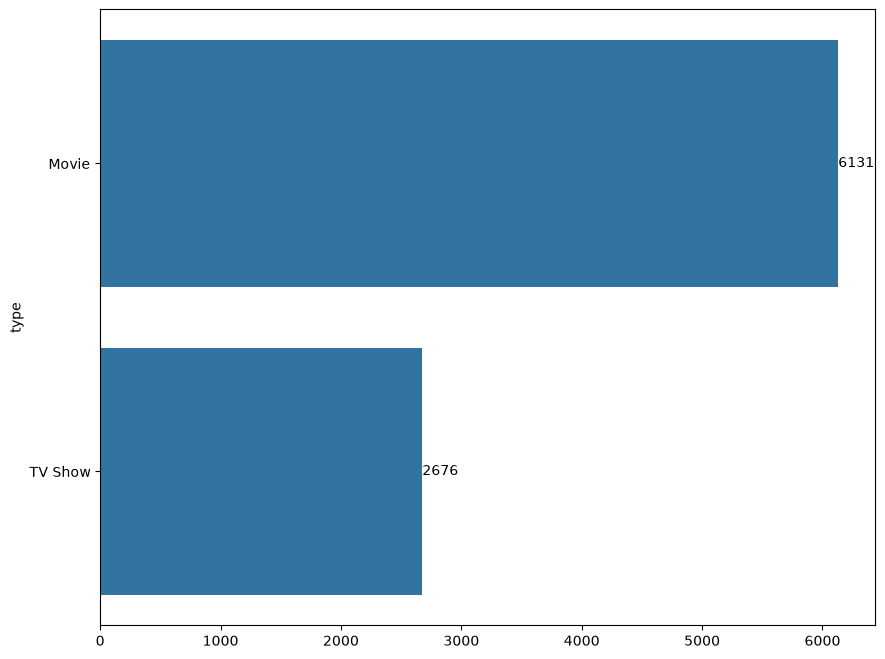

In [28]:
# Dùng type_counts từ câu 3.2 (nếu chưa có thì value_counts lại).
# Your code here
plt.figure(figsize=(10,8))
types_count = df_clean['type'].value_counts()
ax = sns.barplot(x=types_count.values,y = types_count.index)
ax.bar_label(ax.containers[0])

### Câu 3.4 — Nhận xét barplot type (**0,2 đ**)

Nhận xét barplot type (2–3 câu, dựa trên số vừa in):
- Loại nào nhiều hơn? Chiếm khoảng bao nhiêu %?
- Catalog Netflix nghiêng phim hay series?


In [29]:
# Your code here
# Nhận xét
# - Movie chiếm nhiều hơn vượt trội, tận 6131 tựa phim, chiếm 69.6% tổng số
# - Trong khi đó Show chỉ  có 2676 chương trình và chiếm 30.4% tổng số
# - Do đó Netflix sẽ có xu hướng nghiêng hẳng về phim nhiều hơn

### Câu 3.5 — Barplot rating (**0,3 đ**)



Content rating là gì?

Content rating = xếp hạng độ tuổi / đối tượng khán giả của phim và TV show trên Netflix.

| Rating | Ý nghĩa |
|---|---|
| TV-MA | Người lớn, nội dung mạnh |
| TV-14 | Từ khoảng 14 tuổi trở lên |
| TV-PG | Trẻ xem được nếu có hướng dẫn phụ huynh |
| PG-13 | Phim điện ảnh, dưới 13 nên có người lớn đi cùng |
| R | Restricted, dưới 17 cần người lớn |
| TV-Y / TV-G | Trẻ nhỏ / mọi lứa tuổi |




Đếm số lượng theo rating, lấy top 12. Vẽ barplot. Có title, nhãn trục.
Làm tương tự barplot type ở trên. Không copy insight có sẵn.

[Text(0, 0, '3211'),
 Text(0, 0, '2160'),
 Text(0, 0, '863'),
 Text(0, 0, '799'),
 Text(0, 0, '490'),
 Text(0, 0, '334'),
 Text(0, 0, '307'),
 Text(0, 0, '287'),
 Text(0, 0, '220'),
 Text(0, 0, '80'),
 Text(0, 0, '41'),
 Text(0, 0, '6')]

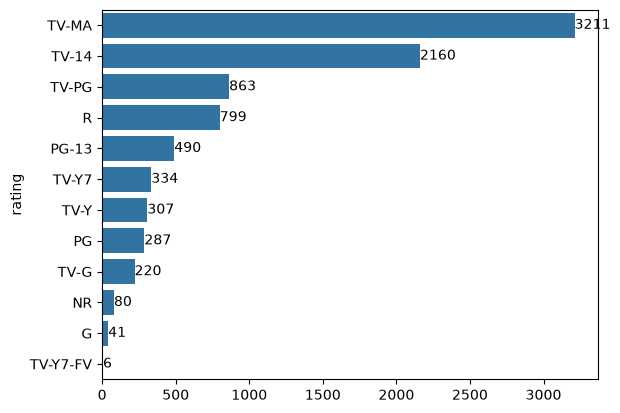

In [30]:
# Your code here
top12_rating = df_clean['rating'].value_counts().head(12)
ax = sns.barplot(x = top12_rating.values,y=top12_rating.index)
ax.bar_label(ax.containers[0])

### Câu 3.6 — Nhận xét barplot rating (**0,2 đ**)

Nhận xét (dựa trên số vừa vẽ):
- Rating nào nhiều nhất? Khoảng bao nhiêu title?
- Catalog nghiêng người lớn, teen, hay trẻ em?


In [31]:
# Your code here
# Nhận xét:
# - Rating có số lượng nhiều nhất là TV-MA, có 3207 chương trình/tựa phim
# - Catalog của Nexflix sẽ tập trung vào đối tuượng là người lớn và có xu hướng xem các nội dung mạnh

### Câu 3.7 — Outlier duration phim (**0,5 đ**)

Cột: duration_int, chỉ các dòng Movie (đơn vị phút). Không dùng TV Show.

Yêu cầu:
1. Boxplot duration phim.
2. Tính IQR: Q1, Q3. 
3. Đếm số điểm ngoài fence.


Q1 = 87.0, Q3 = 114.0, IQR = 27.0
Lower Fence = 46.5, Upper Fence = 154.5
Số lượng điểm outlier: 450


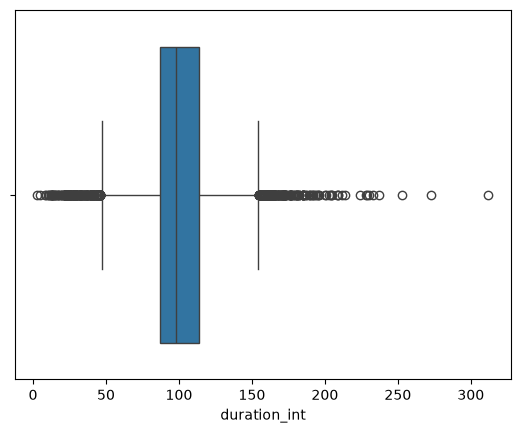

In [32]:
# lưu ý: Lọc type == Movie, lấy duration_int, bỏ NaN
df_movie = df_clean[df_clean['type'] == "Movie"]
duration_movie = df_movie['duration_int'].dropna()
# Your code here
# 1. boxplot duration phim
sns.boxplot(x=duration_movie)

# 2, tinhs iqr,q1,q3
q1 = duration_movie.quantile(0.25)
q3 = duration_movie.quantile(0.75)
iqr = q3 - q1


lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = duration_movie[(duration_movie < lower_fence) | (duration_movie > upper_fence)]

print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}")
print(f"Lower Fence = {lower_fence}, Upper Fence = {upper_fence}")
print(f"Số lượng điểm outlier: {len(outliers)}")

### Câu 3.8 — Quyết định outlier tiếp câu 3.7 (**0,3 đ**)

Quyết định keep / cap / remove outlier của cột này? Vì sao? 


IQR và clip khác nhau ở điểm nào? (**+0,5 đ**)


In [33]:
# Your answer here
# Keep / cap / remove: Kêep
# Lý do: 
#  - QUyết định keep vì khi quan sát biểu đồ ở 3.7 thì có một số phim dưới 50p và dài hơn 150p, thời lượng lượng này rất thật tế với một số loại phim 
# - Nếu xóa thì thì làm mất đi sự đa dạng của phim, khi loại bỏ thì loại bỏ tận 450 bộ phim(outlier) làm sai lệnh dữ liệu

#------------------------
# Sự khác nhau giữa IQR và clip
# IQR đongs vai trò để tính điểm chặn dưới và điểm chặn trên nhằm xác định các điểm ngoại lai trong bộ dữ liệu 
# clip là cách để  cách ép các giá trị vượt ngưỡng(outliner) về đúng giá trị min/max,điểm nào nhỏ hơn ngưỡng dưới thì gán bằng ngưỡng dưới, điểm nào lớn hơn ngưỡng trên thì gán bằng ngưỡng trên
#  


## 3.2 Multivariate analysis


### Câu 3.9 — Correlation (**0,5 đ**)

Corr các cột release_year, year_added, duration_int.

Gợi ý: duration_int Movie. Nên lọc type == Movie trước khi corr.

Yêu cầu:
1. In ma trận corr.
2. Heatmap, có annot.


,release_year,year_added,duration_int
release_year,1.000000,0.039285,-0.206285
year_added,0.039285,1.000000,0.124436
duration_int,-0.206285,0.124436,1.000000


<Axes: >

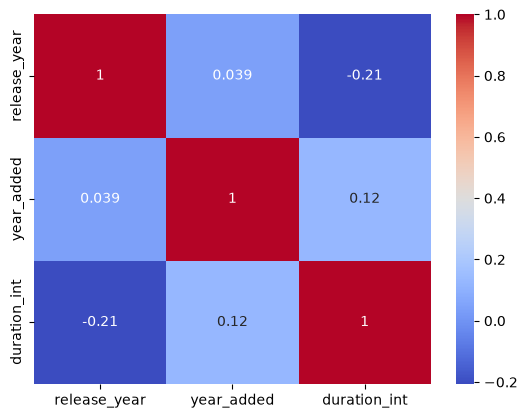

In [34]:
# Your code here
df_movie = df_clean[df_clean['type'] == "Movie"]
duration_movie = df_movie[['release_year','year_added','duration_int']]

corr = duration_movie.corr()
display(corr)

sns.heatmap(data=corr,annot=True,cmap='coolwarm')

### Câu 3.10 — Nhận xét corr (**0,3 đ**)

Nhận xét cặp tương quan nổi bật (dương/âm, mạnh/yếu). Ý nghĩa 1 câu.


In [35]:
# Your answer here
# Cặp tương quan nổi bật là cặp release_year và duration_int với hệ số tương quan là -0.21
# Tương quan âm , mức độ yếu
# Thời lượng phim gần đây có thời lượng ngắn hơn với năm trước đó


# Phần 4 — Summary và insights (**1,0 đ**)

Điền vào chỗ trống. Lấy số từ output đã chạy. Không bịa số.


### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng ...... %. Cột thiếu nhiều nhất là ...... (khoảng ...... %).
Cột nhóm em fill bằng ...... .

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng ...... %, TV Show khoảng ...... %.
Rating phổ biến nhất: ...... .

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (chỉ Movie, phút) có / không có outlier rõ. Em chọn keep / cap / remove vì ......
hoặc
Tương quan: cặp ...... và ...... có corr khoảng ...... (dương/âm, mạnh/yếu). Ý nghĩa: ......


# My answer here

### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng 4.08 %. Cột thiếu nhiều nhất là director (khoảng 29.91%).
Cột nhóm em fill bằng Unknow

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng 69.9 %, TV Show khoảng 30.4 %.
Rating phổ biến nhất: TV-MA (3207)

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (Movie) có450 outlier. Em chọn keep vì các bộ phim có thời lượng duới 50p và trên 150p là hoàn toàn đúng với thực tế, nếu loại bỏ thì làm mất đi sự đa dạng thời gian phim tren netflix

# Encoding 


### Câu B1 — Encoding cột type (**+0,7 đ**)

Cột type nên dùng one-hot hay label? Vì sao? Viết code thực thi.


In [36]:
# Your code here
#Cột type là biến phân loại không có thứ bậc,chir 2 giá trị là Movie và TV Show. Giữa hai loại này không có quan hệ thứ tự hơn kém, lớn bé hay cấp bậc
#Nếu dùng Lable thì nó sẽ thành Movie = 0 và TV Show = 1, các mô hình huấn luyện có thể hiểu nhầm TV Show có gì đó hơn Movie

df_clean['type_encoded'] = df_clean['type'].map({'Movie': 0, 'TV Show': 1})
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_country,primary_genre,duration_int,duration_unit,type_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,United States,Documentaries,90,min,0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,South Africa,International TV Shows,2,Seasons,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,Unknown,Crime TV Shows,1,Season,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,Unknown,Docuseries,1,Season,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,India,International TV Shows,2,Seasons,1


### Câu B2 — Encoding rating / primary_genre (**+0,8 đ**)

Cột rating hoặc primary_genre nên dùng loại nào? Vì sao? Viết code thực thi.


In [37]:
# Your code here

# - Với cột 'rating': Nên dùng Ordinal Encoding vì các nhãn xếp hạng có thứ bậc rõ ràng theo độ tuổi và mức độ kiểm duyệt (từ trẻ nhỏđến người lớn), 
# - Với cột 'primary_genre': Nên dùng One-Hot Encoding vì  không có thứ tự hơn kém giữa các thể loại 
rating_order = {
    'TV-Y': 0, 'TV-Y7': 1, 'TV-Y7-FV': 1,
    'G': 2, 'TV-G': 2, 'PG': 3, 'TV-PG': 3,
    'PG-13': 4, 'TV-14': 5, 'R': 6, 'TV-MA': 7, 'NC-17': 8
}
df_clean['rating_encoded'] = df_clean['rating'].map(rating_order)
df_clean[['rating', 'rating_encoded']].dropna().head()

,rating,rating_encoded
0,PG-13,4.0
1,TV-MA,7.0
2,TV-MA,7.0
3,TV-MA,7.0
4,TV-MA,7.0
